## Best Optimization CV - Employer Bee Algo 2 + Onlooker Bee Algo 3

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train.shape[1]
x_train = gallstone_dataset.x_train
x_test  = gallstone_dataset.x_test
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
mod = "Grid_Optimization"

In [4]:
best_lambda_config = GlobalSetting.get_config_by_type(mod)
best_lamda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lamda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [5]:
abc_relm_cv  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lamda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lamda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_relm_cv.employed_bee_apply_algo3()
abc_relm_cv.init_algo3(initial_probability=0.05,final_probability=0.95)
abc_relm_cv.onlooker_bee_apply_algo2()

In [6]:
results_df , convergence_df , scout_df = abc_testing(abc_relm_cv, x_train, y_train, x_test, y_test)
results_df.describe()

Running simulation for Seed: 161...                                            
ABC Training for 100 iterations.
Iteration 001 complete | Duration: 2.0411s | Scout Triggers: 0 | Best Fitness: 0.726848
Iteration 002 complete | Duration: 2.5564s | Scout Triggers: 0 | Best Fitness: 0.744835
Iteration 003 complete | Duration: 3.1441s | Scout Triggers: 0 | Best Fitness: 0.744835
Iteration 004 complete | Duration: 2.1146s | Scout Triggers: 0 | Best Fitness: 0.744835
Iteration 005 complete | Duration: 1.9444s | Scout Triggers: 0 | Best Fitness: 0.744835
Iteration 006 complete | Duration: 2.7336s | Scout Triggers: 0 | Best Fitness: 0.744835
Iteration 007 complete | Duration: 1.8207s | Scout Triggers: 0 | Best Fitness: 0.744835
Iteration 008 complete | Duration: 1.6601s | Scout Triggers: 0 | Best Fitness: 0.744835
Iteration 009 complete | Duration: 1.6644s | Scout Triggers: 0 | Best Fitness: 0.744835
Iteration 010 complete | Duration: 1.9251s | Scout Triggers: 0 | Best Fitness: 0.744835
Iterati

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.768229,0.784600,0.742708,0.756521,0.793750,0.761808,0.749957,0.768229,0.538776,175.500000
std,0.035556,0.045143,0.052345,0.038841,0.052931,0.037637,0.045007,0.035556,0.071556,8.803408
min,0.687500,0.705882,0.625000,0.666667,0.687500,0.666667,0.641026,0.687500,0.377964,161.000000
25%,0.738281,0.757576,0.718750,0.730631,0.750000,0.737247,0.724415,0.738281,0.481179,168.250000
50%,0.781250,0.787879,0.750000,0.756757,0.781250,0.769231,0.743639,0.781250,0.563051,175.500000
75%,0.796875,0.819775,0.781250,0.787879,0.843750,0.793651,0.786164,0.796875,0.594040,182.750000
max,0.812500,0.857143,0.843750,0.833333,0.875000,0.818182,0.833333,0.812500,0.629941,190.000000


In [9]:
results_df

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
0,0.703125,0.709677,0.68750,0.696970,0.71875,0.698413,0.691824,0.703125,0.406449,161
1,0.796875,0.806452,0.78125,0.787879,0.81250,0.793651,0.786164,0.796875,0.594040,162
2,0.796875,0.806452,0.78125,0.787879,0.81250,0.793651,0.786164,0.796875,0.594040,163
3,0.750000,0.766667,0.71875,0.735294,0.78125,0.741935,0.727848,0.750000,0.500979,164
4,0.765625,0.840000,0.65625,0.717949,0.87500,0.736842,0.686275,0.765625,0.544436,165
5,0.734375,0.777778,0.65625,0.702703,0.81250,0.711864,0.677419,0.734375,0.474579,166
6,0.734375,0.741935,0.71875,0.727273,0.75000,0.730159,0.723270,0.734375,0.468979,167
7,0.765625,0.814815,0.68750,0.729730,0.84375,0.745763,0.709677,0.765625,0.537856,168
8,0.796875,0.827586,0.75000,0.771429,0.84375,0.786885,0.764331,0.796875,0.596377,169
9,0.796875,0.851852,0.71875,0.756757,0.87500,0.779661,0.741935,0.796875,0.601133,170


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_F1-Score.png


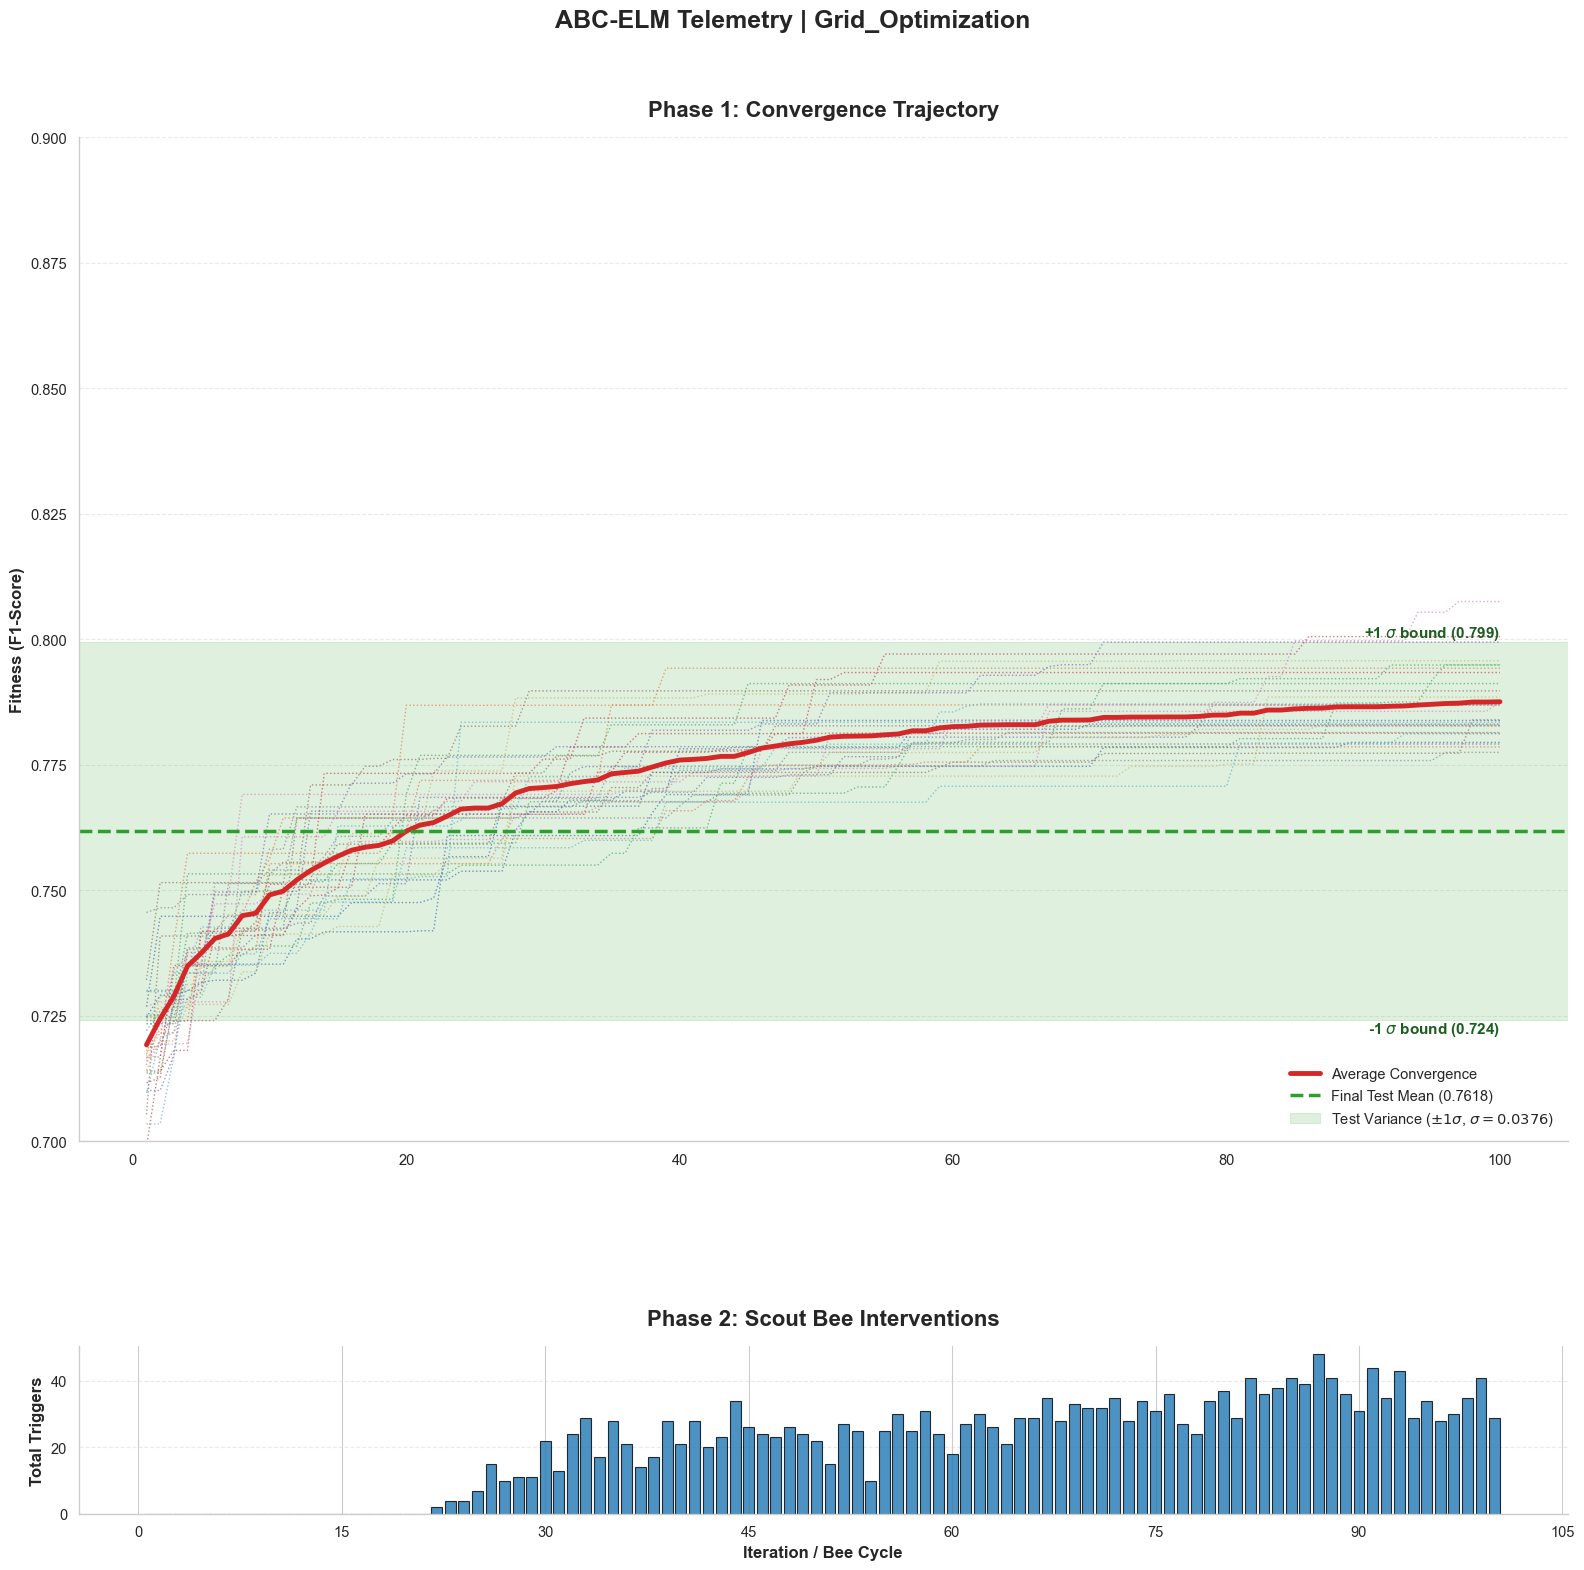

In [11]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [10]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Scout_History.csv
